In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold3_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold3_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold3_05["fold"] = [3 for i in range(len(fold3_05))]
fold3_05["target"] = [-0.5 for i in range(len(fold3_05))]

In [6]:
fold4_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold4_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold4_05["fold"] = [4 for i in range(len(fold4_05))]
fold4_05["target"] = [-0.5 for i in range(len(fold4_05))]

In [7]:
fold5_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold5_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold5_05["fold"] = [5 for i in range(len(fold5_05))]
fold5_05["target"] = [-0.5 for i in range(len(fold5_05))]

In [8]:
fold6_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold6_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold6_05["fold"] = [6 for i in range(len(fold6_05))]
fold6_05["target"] = [-0.5 for i in range(len(fold6_05))]

In [9]:
fold7_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold7_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold7_05["fold"] = [7 for i in range(len(fold7_05))]
fold7_05["target"] = [-0.5 for i in range(len(fold7_05))]

In [10]:
df = pd.concat([fold0_05, fold1_05, fold2_05,
                fold3_05, fold4_05, fold5_05,
                fold6_05, fold7_05,], ignore_index=True)

In [11]:
len(df)

406

In [12]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [13]:
# Define optimization success
df["optimization_success"] = df["URQ_delta"] < 0

In [14]:
len(df[df["optimization_success"] == True]), len(df[df["optimization_success"] == False])

(352, 54)

In [15]:
unsuccessful_all_folds = df[df["optimization_success"] == False]
unsuccessful_all_folds.reset_index(drop=True, inplace=True)

In [16]:
unsuccessful_all_folds.to_csv(f"/scratch1/smaruj/generate_genomic_boundary/unsuccessful_all_folds_-0.5.tsv", sep="\t", index=False)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'URQ_result', 'URQ_target', 'URQ_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'target',
       'URQ_delta', 'optimization_success'],
      dtype='object')

### Active chromatin fraction

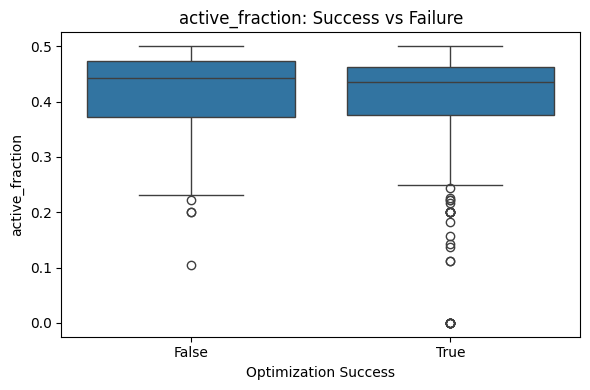

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="active_fraction"
)
plt.title(f"active_fraction: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("active_fraction")
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import mannwhitneyu

In [21]:
group_success = df[df["optimization_success"] == True]["active_fraction"]
group_fail = df[df["optimization_success"] == False]["active_fraction"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 8616.5
pvalue = 0.2689674256676907


### Neutral chromatin fraction

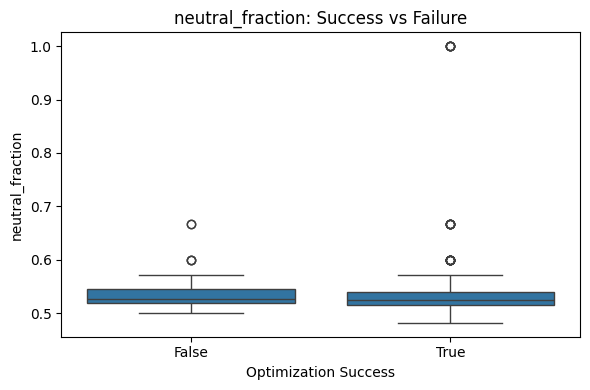

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="neutral_fraction"
)
plt.title(f"neutral_fraction: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("neutral_fraction")
plt.tight_layout()
plt.show()

In [23]:
group_success = df[df["optimization_success"] == True]["neutral_fraction"]
group_fail = df[df["optimization_success"] == False]["neutral_fraction"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 8775.5
pvalue = 0.3633703364681563


### Repressive chromatin fraction

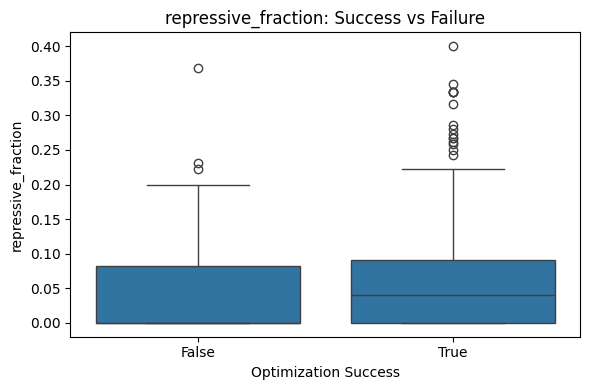

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="repressive_fraction"
)
plt.title(f"repressive_fraction: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("repressive_fraction")
plt.tight_layout()
plt.show()

In [25]:
group_success = df[df["optimization_success"] == True]["repressive_fraction"]
group_fail = df[df["optimization_success"] == False]["repressive_fraction"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 10487.0
pvalue = 0.20484762861771455


### initial URQ mean

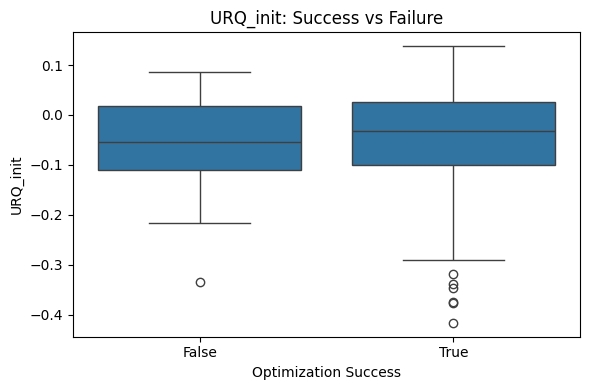

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="URQ_init"
)
plt.title(f"URQ_init: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("URQ_init")
plt.tight_layout()
plt.show()

In [27]:
group_success = df[df["optimization_success"] == True]["URQ_init"]
group_fail = df[df["optimization_success"] == False]["URQ_init"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 10259.0
pvalue = 0.34737676738189693


### GC content of the entire input

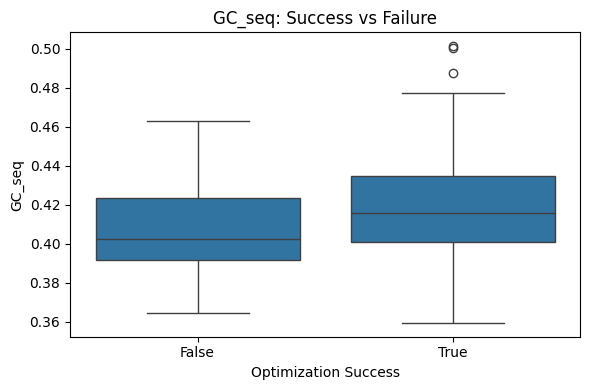

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="GC_seq"
)
plt.title(f"GC_seq: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("GC_seq")
plt.tight_layout()
plt.show()

In [29]:
group_success = df[df["optimization_success"] == True]["GC_seq"]
group_fail = df[df["optimization_success"] == False]["GC_seq"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 12110.0
pvalue = 0.0011744574485850377


### GC content of the edited slice

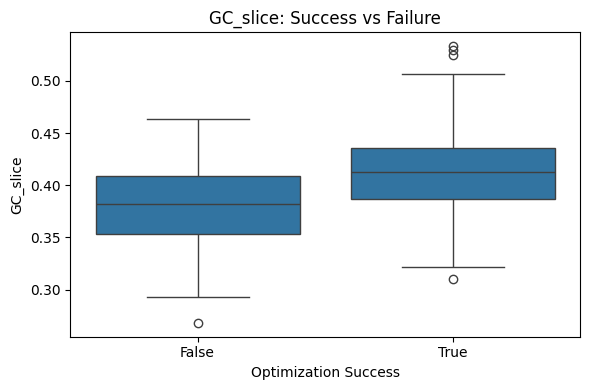

In [30]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="GC_slice"
)
plt.title(f"GC_slice: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("GC_slice")
plt.tight_layout()
plt.show()

In [31]:
group_success = df[df["optimization_success"] == True]["GC_slice"]
group_fail = df[df["optimization_success"] == False]["GC_slice"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 13667.0
pvalue = 2.1685853941557963e-07


### Initial number of CTCFs

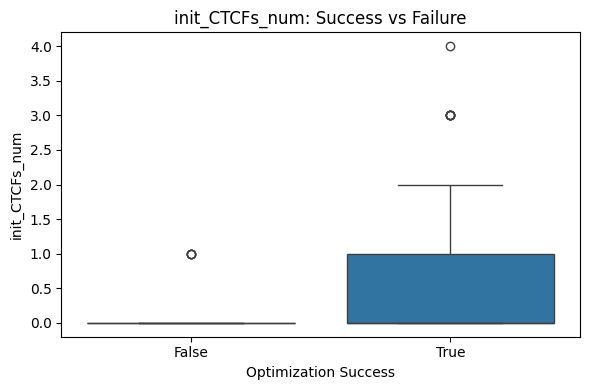

In [32]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="init_CTCFs_num"
)
plt.title(f"init_CTCFs_num: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("init_CTCFs_num")
plt.tight_layout()
plt.show()

In [33]:
group_success = df[df["optimization_success"] == True]["init_CTCFs_num"]
group_fail = df[df["optimization_success"] == False]["init_CTCFs_num"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 12420.0
pvalue = 1.1808288145858054e-05


### CTCF-like content

In [34]:
from pyfaidx import Fasta

In [35]:
from tqdm import tqdm

In [36]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [37]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    return seq

In [38]:
def reverse_complement(seq: str) -> str:
    complement = str.maketrans("ACGTN", "TGCAN")  # include N if needed
    return seq.translate(complement)[::-1]

In [39]:
# estimating background probabilities - all genomic regions with successful optimizations

from collections import Counter

# Initialize counter
total_counts = Counter()
total_bases = 0

for _, row in df.iterrows():
    # read sequence from genome
    seq = get_sequence(genome, row["chrom"], row["centered_start"], row["centered_end"])
    seq = seq.upper()
    
    # count nucleotides in this sequence
    counts = Counter(seq)
    
    # keep only A/C/G/T
    for b in "ACGT":
        total_counts[b] += counts.get(b, 0)
    
    # accumulate total base count
    total_bases += sum(counts[b] for b in "ACGT")

# calculate background probabilities
bg_probs = {b: total_counts[b] / total_bases for b in "ACGT"}
print("Estimated background probabilities:", bg_probs)

Estimated background probabilities: {'A': 0.2914815568579609, 'C': 0.20858388788289478, 'G': 0.20843395842776274, 'T': 0.29150059683138163}


In [40]:
def seq_score(seq, pwm, bg=None, pseudocount=1e-9):
    """
    seq: DNA sequence (string)
    pwm: numpy array of shape (length, 4)
    bg: dict of background probabilities, e.g., {'A':0.29, 'C':0.21, 'G':0.21, 'T':0.29}
    pseudocount: small value to avoid log(0)
    """
    if bg is None:
        bg = {'A':0.25, 'C':0.25, 'G':0.25, 'T':0.25}

    base_idx = {'A':0, 'C':1, 'G':2, 'T':3}
    score = 0.0
    seq = seq.upper()
    
    for i, b in enumerate(seq):
        if b not in base_idx:
            continue  # skip Ns or unexpected bases
        p = pwm[i, base_idx[b]]
        p = max(p, pseudocount)
        score += np.log2(p / bg[b])  # use bg for this base
    return score

In [41]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [42]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [43]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)

In [44]:
# Reverse one-hot encoding
def ohe_to_seq(ohe_tensor):
    bases = np.array(['A', 'C', 'G', 'T'])
    # ohe_tensor shape (1, 4, L)
    ohe = ohe_tensor.squeeze(0).cpu().detach().numpy()  # (4, L)
    seq_idx = np.argmax(ohe, axis=0)
    return ''.join(bases[seq_idx])

In [45]:
# Sliding score calculation
def sliding_scores(seq, pwm, step=1):
    window = pwm.shape[0]
    scores = []
    for i in range(0, len(seq) - window + 1, step):
        window_seq = seq[i:i+window]
        score = seq_score(window_seq, pwm)
        scores.append(score)
    return np.array(scores)

In [46]:
def reverse_complement_pwm(pwm):
    # Columns: 0:A, 1:C, 2:G, 3:T
    rev_pwm = pwm[::-1, :].copy()
    rev_pwm = rev_pwm[:, [3, 2, 1, 0]]  # swap A↔T and C↔G
    return rev_pwm

In [47]:
pwm_CTCF_rc = reverse_complement_pwm(pwm_CTCF)

In [49]:
# Iterate over table

# Initialize new columns with default values
df['num_positive_peaks'] = 0
df['sum_scores'] = 0.0
df['sum_positive_scores'] = 0.0
df['max_CTCF_score'] = 0.0

for i, row in tqdm(df.iterrows(), total=len(df)):
    chrom = row["chrom"]
    start = row["centered_start"]
    end = row["centered_end"]
    fold = row["fold"]
    
    # Extract the sequence around the region
    seq = get_sequence(genome, chrom, start + 655360 - 9, start + 657408 + 9)
    
    # Compute sliding scores
    scores = sliding_scores(seq, pwm_CTCF, step=1)
    scores_rev = sliding_scores(seq, pwm_CTCF_rc, step=1)
    
    # Combine forward and reverse scores
    scores_combined = np.maximum(scores, scores_rev)
    
    # Compute summary stats
    positive_mask = scores_combined > 0
    num_positive_peaks = int(np.sum(positive_mask))
    sum_positive_scores = float(np.sum(scores_combined[positive_mask]))
    sum_scores = float(np.sum(scores_combined))
    max_score = float(np.max(scores_combined))  # maximum score
    
    # Add stats to df
    df.at[i, 'num_positive_peaks'] = num_positive_peaks
    df.at[i, 'sum_positive_scores'] = sum_positive_scores
    df.at[i, 'sum_scores'] = sum_scores
    df.at[i, 'max_CTCF_score'] = max_score
    
    # print("num of peaks", num_positive_peaks)
    # print("sum", sum_positive_scores)
    
    # x = np.arange(len(scores))
    
    # plt.figure(figsize=(8, 4))
    # plt.plot(x, scores, label="Forward", color="steelblue")
    # plt.plot(x, scores_rev, label="Reverse complement", color="tomato")
    
    # plt.title(f"{row['chrom']}:{row['centered_start']}-{row['centered_end']}  (fold {row['fold']})")
    # plt.xlabel("Position relative to optimized region (bp)")
    # plt.ylabel("CTCF-like information score")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


100%|██████████| 406/406 [00:28<00:00, 14.18it/s]


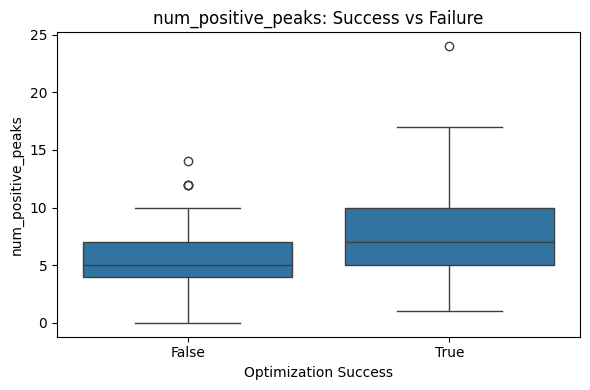

In [50]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="num_positive_peaks"
)
plt.title(f"num_positive_peaks: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("num_positive_peaks")
plt.tight_layout()
plt.show()

In [51]:
group_success = df[df["optimization_success"] == True]["num_positive_peaks"]
group_fail = df[df["optimization_success"] == False]["num_positive_peaks"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 13243.5
pvalue = 2.9205188594920734e-06


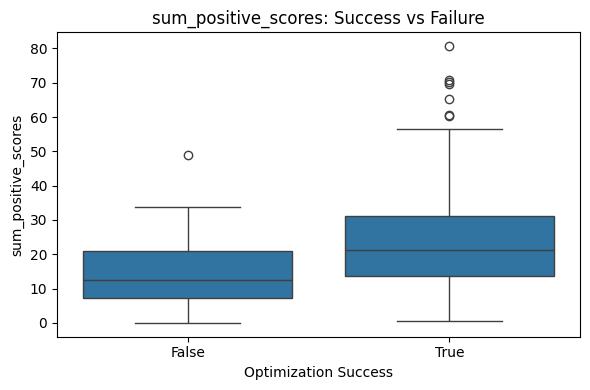

In [53]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="sum_positive_scores"
)
plt.title(f"sum_positive_scores: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("sum_positive_scores")
plt.tight_layout()
plt.show()

In [54]:
group_success = df[df["optimization_success"] == True]["sum_positive_scores"]
group_fail = df[df["optimization_success"] == False]["sum_positive_scores"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 13596.0
pvalue = 3.473708310918965e-07


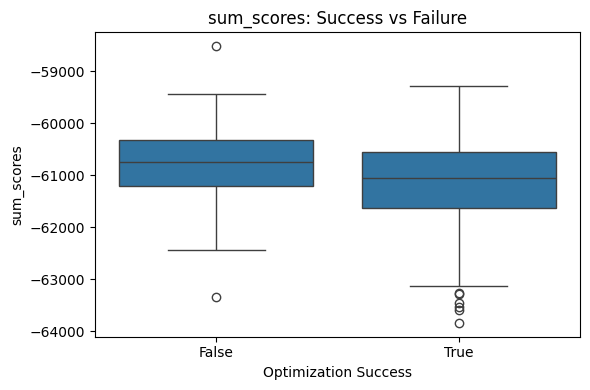

In [58]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="sum_scores"
)
plt.title(f"sum_scores: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("sum_scores")
plt.tight_layout()
plt.show()

In [59]:
group_success = df[df["optimization_success"] == True]["sum_scores"]
group_fail = df[df["optimization_success"] == False]["sum_scores"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 7355.0
pvalue = 0.00745416419543722


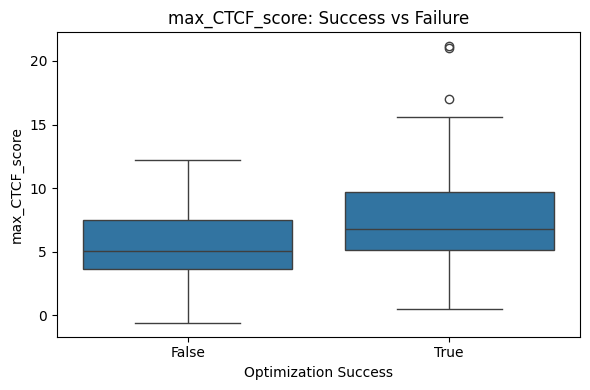

In [60]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x="optimization_success",
    y="max_CTCF_score"
)
plt.title(f"max_CTCF_score: Success vs Failure")
plt.xlabel("Optimization Success")
plt.ylabel("max_CTCF_score")
plt.tight_layout()
plt.show()

In [61]:
group_success = df[df["optimization_success"] == True]["max_CTCF_score"]
group_fail = df[df["optimization_success"] == False]["max_CTCF_score"]

stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
print("stat =", stat)
print("pvalue =", pvalue)

stat = 12963.5
pvalue = 1.6473266745776874e-05


### Is there a good threshold distinguising successes from failures?

In [55]:
from sklearn.metrics import roc_curve, auc

Best threshold: 24.664720437616705
Sensitivity (TPR) at threshold: 0.4090909090909091
Specificity (1-FPR) at threshold: 0.9074074074074074


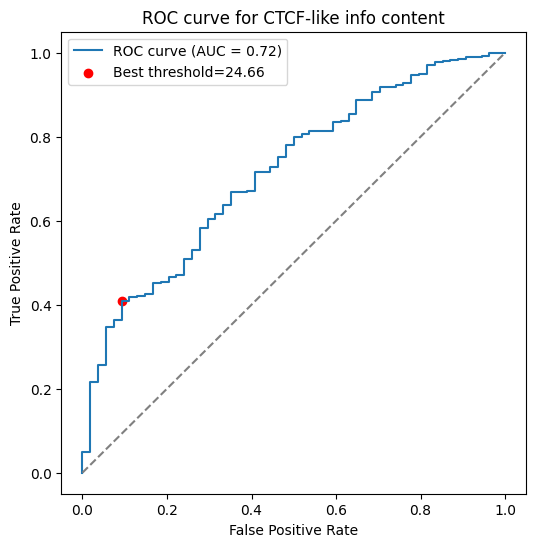

In [56]:

# X = CTCF-like info content
X = df["sum_positive_scores"].values  # or "num_positive_peaks", depending on what you want
y = df["optimization_success"].astype(int).values

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, X)
roc_auc = auc(fpr, tpr)

# Find the threshold maximizing Youden's J statistic (tpr - fpr)
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Sensitivity (TPR) at threshold:", tpr[best_idx])
print("Specificity (1-FPR) at threshold:", 1-fpr[best_idx])

# Optional: plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for CTCF-like info content')
plt.legend()
plt.show()

In [ ]:
df.columns

Best threshold: 7.732992518465807
Sensitivity (TPR) at threshold: 0.4289772727272727
Specificity (1-FPR) at threshold: 0.8703703703703703


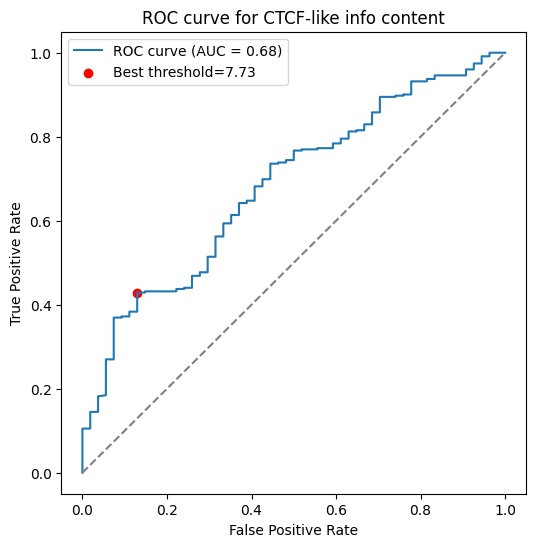

In [57]:
# X = CTCF-like info content
X = df["max_CTCF_score"].values  # or "num_positive_peaks", depending on what you want
y = df["optimization_success"].astype(int).values

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, X)
roc_auc = auc(fpr, tpr)

# Find the threshold maximizing Youden's J statistic (tpr - fpr)
J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Sensitivity (TPR) at threshold:", tpr[best_idx])
print("Specificity (1-FPR) at threshold:", 1-fpr[best_idx])

# Optional: plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for CTCF-like info content')
plt.legend()
plt.show()

In [64]:
# df[df["max_CTCF_score"] > 0]

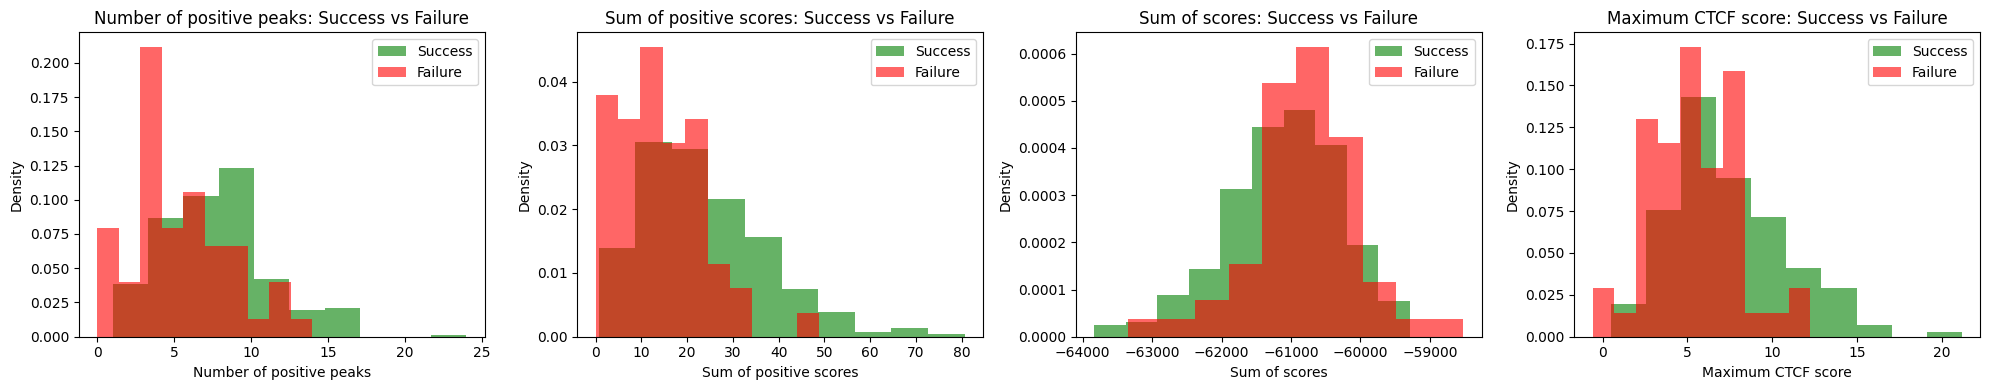

In [66]:
metrics = ['num_positive_peaks', 'sum_positive_scores', 'sum_scores', 'max_CTCF_score']
titles = ['Number of positive peaks', 'Sum of positive scores',  'Sum of scores', 'Maximum CTCF score']

plt.figure(figsize=(20, 4))

for i, (metric, title) in enumerate(zip(metrics, titles), 1):
    plt.subplot(1, 4, i)
    
    # Histogram for successful optimizations
    plt.hist(
        df[df['optimization_success'] == True][metric],
        bins=10, alpha=0.6, label='Success', color='green', density=True
    )
    
    # Histogram for unsuccessful optimizations
    plt.hist(
        df[df['optimization_success'] == False][metric],
        bins=10, alpha=0.6, label='Failure', color='red', density=True
    )
    
    plt.xlabel(title)
    plt.ylabel('Density')
    plt.title(title + ': Success vs Failure')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(5, 4))

metric = 'sum_positive_scores'
title = 'Sum of positive scores'

# Success
plt.hist(
    df[df['optimization_success'] == True][metric],
    bins=10, alpha=0.6, label='Success', color='green', density=False
)

# Failure
plt.hist(
    df[df['optimization_success'] == False][metric],
    bins=10, alpha=0.6, label='Failure', color='red', density=False
)

plt.xlabel(title)
plt.ylabel('Count')
# plt.title(title + ': Success vs Failure')
plt.legend()
plt.tight_layout()

plt.savefig("success_failure_optimization.svg", format="svg")

plt.show()

### What is a typical motif score after optimization?

In [ ]:
import torch

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [ ]:
import random

In [ ]:
slice_0_start = 655360
slice_0_end = 657408

In [ ]:
after_num_positive_peaks = []
after_sum_positive_scores = []
after_max_score = []

for row in df[df["optimization_success"] == True].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[chrom][pred_start:pred_end]

    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)

    # modifying X
    X_mod = X_tensor.clone()

    mod_slice = torch.load(
        f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold{row.fold}/{chrom}_{pred_start}_{pred_end}_slice.pt",
        map_location=device
    )

    X_mod[0, :, slice_0_start:slice_0_end] = mod_slice[0, :, :]

    slice_to_scan = X_mod[:, :, slice_0_start-9:slice_0_end+9]
    
    seq = ohe_to_seq(slice_to_scan)
    
    # Compute sliding scores
    scores = sliding_scores(seq, pwm_CTCF, step=1)
    scores_rev = sliding_scores(seq, pwm_CTCF_rc, step=1)
    
    # Combine forward and reverse scores
    scores_combined = np.maximum(scores, scores_rev)
    
    # Compute summary stats
    positive_mask = scores_combined > 0
    num_positive_peaks = int(np.sum(positive_mask))
    sum_positive_scores = float(np.sum(scores_combined[positive_mask]))
    max_score = float(np.max(scores_combined)) 
    
    after_num_positive_peaks.append(num_positive_peaks)
    after_sum_positive_scores.append(sum_positive_scores)
    after_max_score.append(max_score)

In [ ]:
# Data
success_scores = df[df["optimization_success"] == True]["max_CTCF_score"]
after_scores = after_max_score  # assuming this is a list or array of values

plt.figure(figsize=(7,5))

# Histogram for successful optimizations
plt.hist(success_scores, bins=20, alpha=0.6, label='before', color='green', density=True)

# Histogram for after_max_score
plt.hist(after_scores, bins=20, alpha=0.6, label='after', color='blue', density=True)

plt.xlabel('Maximum CTCF Score')
plt.ylabel('Density')
plt.title('Comparison of max_CTCF_score distributions - successful optimizations')
plt.legend()
plt.tight_layout()
plt.show()

### Dinucleotide content - the entire input sequence

In [ ]:
# Function to compute dinucleotide frequencies
def dinucleotide_content(seq):
    seq = seq.upper()
    dinucs = [seq[i:i+2] for i in range(len(seq)-1)]
    counts = Counter(dinucs)
    valid_dinucs = [a+b for a in "ACGT" for b in "ACGT"]
    counts = {k: counts.get(k, 0) for k in valid_dinucs}
    total = sum(counts.values())
    freqs = {k: v / total if total > 0 else 0 for k, v in counts.items()}
    return freqs

In [ ]:
# Add new columns to the DataFrame
dinucs = [a+b for a in "ACGT" for b in "ACGT"]
for dinuc in dinucs:
    df[f"{dinuc}_seq"] = 0.0  # initialize columns


# Loop over sequences
for i, row in tqdm(df.iterrows(), total=len(df)):
    chrom = row["chrom"]
    start = row["centered_start"]
    end = row["centered_end"]
    fold = row["fold"]

    # Get the sequence (replace with your actual function)
    seq = get_sequence(genome, chrom, start, end)
    
    # Compute dinucleotide content
    freqs = dinucleotide_content(seq)
    
    # Assign to DataFrame
    for dinuc, val in freqs.items():
        df.at[i, f"{dinuc}_seq"] = val

In [ ]:
# List of dinucleotide columns
dinucs = [a+b for a in "ACGT" for b in "ACGT"]
dinuc_cols = [f"{d}_seq" for d in dinucs]

In [ ]:
# Define the layout: e.g., 4 rows x 4 columns
n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(dinuc_cols):
    sns.boxplot(
        data=df,
        x="optimization_success",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Fraction")

# Remove any empty subplots (in case n_rows*n_cols > 16)
for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
results = []

for col in dinuc_cols:
    group_success = df[df["optimization_success"] == True][col]
    group_fail = df[df["optimization_success"] == False][col]

    stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
    results.append({"dinucleotide": col, "U_stat": stat, "p_value": pvalue})

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df)

### Dinucleotide content - edited slice

In [ ]:
# Add new columns to the DataFrame
dinucs = [a+b for a in "ACGT" for b in "ACGT"]
for dinuc in dinucs:
    df[f"{dinuc}_slice"] = 0.0  # initialize columns

In [ ]:
# Add new columns to the DataFrame
dinucs = [a+b for a in "ACGT" for b in "ACGT"]
for dinuc in dinucs:
    df[f"{dinuc}_slice"] = 0.0  # initialize columns


# Loop over sequences
for i, row in tqdm(df.iterrows(), total=len(df)):
    chrom = row["chrom"]
    start = row["centered_start"]
    end = row["centered_end"]
    fold = row["fold"]

    # Get the sequence (replace with your actual function)
    seq = get_sequence(genome, chrom, start + 655360, end + 657408)
    
    # Compute dinucleotide content
    freqs = dinucleotide_content(seq)
    
    # Assign to DataFrame
    for dinuc, val in freqs.items():
        df.at[i, f"{dinuc}_slice"] = val

In [ ]:
# List of dinucleotide columns
dinuc_cols_slice = [f"{d}_slice" for d in dinucs]

In [ ]:
# Define the layout: e.g., 4 rows x 4 columns
n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(dinuc_cols_slice):
    sns.boxplot(
        data=df,
        x="optimization_success",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Fraction")

# Remove any empty subplots (in case n_rows*n_cols > 16)
for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
results = []

for col in dinuc_cols_slice:
    group_success = df[df["optimization_success"] == True][col]
    group_fail = df[df["optimization_success"] == False][col]

    stat, pvalue = mannwhitneyu(group_success, group_fail, alternative="two-sided")
    results.append({"dinucleotide": col, "U_stat": stat, "p_value": pvalue})

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df)